**Data Cleaning**

In [ ]:
import pandas as pd
df=pd.read_csv("/content/energy-data.csv")
df.head()


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [ ]:
df.shape

(23232, 130)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23232 entries, 0 to 23231
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


In [ ]:
df.isnull().sum()

,0
country,0
year,0
iso_code,6098
population,4472
gdp,11452
...,...
wind_elec_per_capita,14995
wind_electricity,13904
wind_energy_per_capita,18087
wind_share_elec,15749


In [ ]:
df.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,23232.000000,1.876000e+04,1.178000e+04,2070.000000,7903.000000,6338.000000,8057.000000,5796.000000,6107.000000,6082.000000,...,7640.000000,6379.000000,2798.000000,6293.000000,6405.000000,8237.000000,9328.000000,5145.000000,7483.000000,6379.000000
mean,1975.937543,1.057591e+08,4.257565e+11,43.478821,1.054261,55.157109,15.092053,71.064594,12.190516,1.962601,...,0.970065,0.219811,290.408295,6.021235,48.691258,68.159535,19.811565,214.958708,1.655012,0.518142
std,35.234386,4.697550e+08,3.507870e+12,286.672304,6.641947,180.660547,75.942537,202.044886,51.641143,5.356649,...,2.961908,0.766123,6070.498588,34.260035,281.755752,275.338843,117.845094,733.879417,4.909755,1.722173
min,1900.000000,1.776000e+03,1.642060e+08,-100.000000,-59.083984,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-46.534790,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.000000,1.600333e+06,1.426394e+10,-0.968287,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.328556,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1985.000000,6.950666e+06,4.357680e+10,6.695433,0.000000,0.000000,0.000000,0.874193,0.020000,0.153357,...,0.000000,0.000000,18.349456,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,2.575218e+07,1.830576e+11,23.320313,0.000000,0.506788,0.061667,44.114410,0.920000,1.607833,...,0.214934,0.005892,45.211092,0.095950,0.915601,1.854649,0.120000,25.914005,0.564788,0.074523
max,2025.000000,8.161973e+09,1.301126e+14,6373.061523,144.289948,2587.707520,1366.878296,2450.790527,704.809998,77.586205,...,50.000000,9.881398,242384.859375,642.616699,6124.465332,3947.840332,2505.350098,9315.287109,58.357021,26.085308


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

biofuel_cons_change_pct             21162
solar_cons_change_pct               20717
nuclear_cons_change_pct             20653
wind_cons_change_pct                20434
other_renewables_cons_change_pct    19244
                                    ...  
iso_code                             6098
gas_production                       5981
oil_prod_change_twh                  5503
oil_production                       5240
population                           4472
Length: 128, dtype: int64


In [ ]:
print("Countries:", df["country"].nunique())
print("Years:", df["year"].min(), "-", df["year"].max())

Countries: 314
Years: 1900 - 2025


In [ ]:
print(df["country"].unique()[:20])

['ASEAN (Ember)' 'Afghanistan' 'Africa' 'Africa (EI)' 'Africa (EIA)'
 'Africa (Ember)' 'Africa (Shift)' 'Albania' 'Algeria' 'American Samoa'
 'Angola' 'Antarctica' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Asia (Ember)' 'Asia Pacific (EI)' 'Asia and Oceania (EIA)']


In [ ]:
print(df.describe().T)

                           count          mean           std           min  \
year                     23232.0  1.975938e+03  3.523439e+01  1.900000e+03   
population               18760.0  1.057591e+08  4.697550e+08  1.776000e+03   
gdp                      11780.0  4.257565e+11  3.507870e+12  1.642060e+08   
biofuel_cons_change_pct   2070.0  4.347882e+01  2.866723e+02 -1.000000e+02   
biofuel_cons_change_twh   7903.0  1.054261e+00  6.641947e+00 -5.908398e+01   
...                          ...           ...           ...           ...   
wind_elec_per_capita      8237.0  6.815953e+01  2.753388e+02  0.000000e+00   
wind_electricity          9328.0  1.981157e+01  1.178451e+02  0.000000e+00   
wind_energy_per_capita    5145.0  2.149587e+02  7.338794e+02  0.000000e+00   
wind_share_elec           7483.0  1.655012e+00  4.909755e+00  0.000000e+00   
wind_share_energy         6379.0  5.181422e-01  1.722173e+00  0.000000e+00   

                                  25%           50%           7

**data-quality report**

In [ ]:
quality_report = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Missing_Values": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100,
    "Unique_Values": df.nunique()
})

quality_report.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
biofuel_cons_change_pct,float64,21162,91.089876,1801
solar_cons_change_pct,float64,20717,89.174415,2208
nuclear_cons_change_pct,float64,20653,88.898933,2357
wind_cons_change_pct,float64,20434,87.956267,2434
other_renewables_cons_change_pct,float64,19244,82.834022,3730
...,...,...,...,...
oil_prod_change_twh,float64,5503,23.687156,8521
oil_production,float64,5240,22.555096,8574
population,float64,4472,19.249311,18699
year,int64,0,0.000000,126


**EDA**

**How has global renewable-energy adoption changed over time?**

In [ ]:
global_renewable = (
    df.groupby("year")["renewables_share_energy"]
      .mean()
      .reset_index()
)

print(global_renewable.head())

   year  renewables_share_energy
0  1900                      NaN
1  1901                      NaN
2  1902                      NaN
3  1903                      NaN
4  1904                      NaN


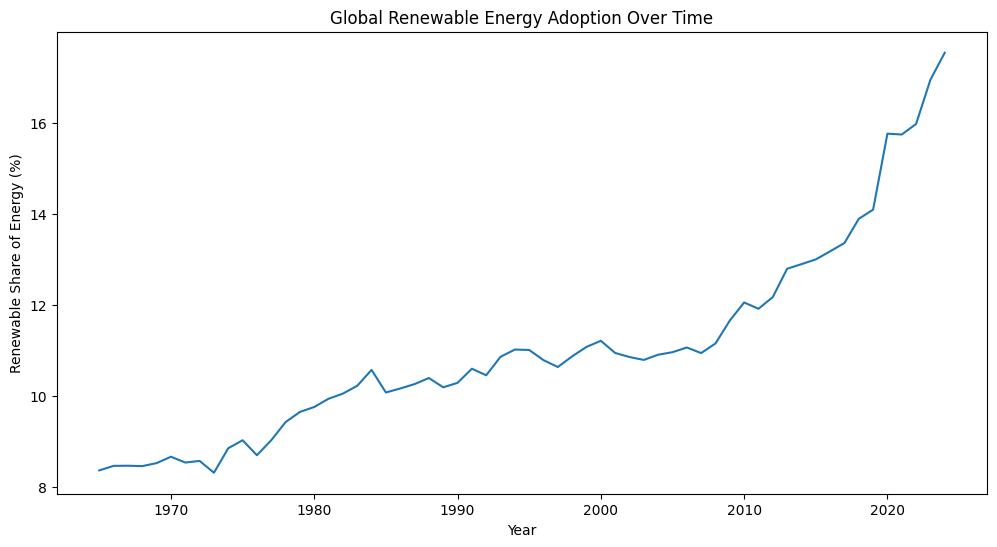

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    global_renewable["year"],
    global_renewable["renewables_share_energy"]
)

plt.xlabel("Year")
plt.ylabel("Renewable Share of Energy (%)")
plt.title("Global Renewable Energy Adoption Over Time")

plt.show()

**Clean the dataset**

In [ ]:
clean_df = df.copy()

In [ ]:
clean_df = clean_df.drop_duplicates()

print(clean_df.shape)

(23232, 130)


In [ ]:
numeric_cols = clean_df.select_dtypes(include="number").columns

for col in numeric_cols:
    negative_count = (clean_df[col] < 0).sum()
    if negative_count > 0:
        print(col, ":", negative_count, "negative values")

biofuel_cons_change_pct : 569 negative values
biofuel_cons_change_twh : 569 negative values
coal_cons_change_pct : 2486 negative values
coal_cons_change_twh : 2486 negative values
coal_prod_change_pct : 3797 negative values
coal_prod_change_twh : 3797 negative values
energy_cons_change_pct : 3727 negative values
energy_cons_change_twh : 3727 negative values
fossil_cons_change_pct : 1824 negative values
fossil_cons_change_twh : 1824 negative values
gas_cons_change_pct : 1525 negative values
gas_cons_change_twh : 1525 negative values
gas_prod_change_pct : 2216 negative values
gas_prod_change_twh : 2216 negative values
hydro_cons_change_pct : 2090 negative values
hydro_cons_change_twh : 2164 negative values
low_carbon_cons_change_pct : 1605 negative values
low_carbon_cons_change_twh : 1700 negative values
net_elec_imports : 1424 negative values
net_elec_imports_share_demand : 1424 negative values
nuclear_cons_change_pct : 821 negative values
nuclear_cons_change_twh : 881 negative values
o

**We want to measure the energy transition.**

In [ ]:
clean_df["renewable_share"] = (
    clean_df["renewables_share_energy"]
)

In [ ]:
clean_df["renewable_electricity_share"] = (
    clean_df["renewables_share_elec"]
)

In [ ]:
clean_df["energy_intensity"] = clean_df["energy_per_gdp"]

In [ ]:
print(clean_df["year"].unique()[-10:])

[1991 1992 1993 1994 1995 1996 1997 1998 1999 2025]


In [ ]:
print(clean_df["year"].min())
print(clean_df["year"].max())

1900
2025


In [ ]:
print(
    clean_df.groupby("year")["renewables_share_energy"]
    .count()
    .tail(10)
)

year
2016    111
2017    111
2018    111
2019    111
2020    111
2021    111
2022    111
2023    111
2024    111
2025      0
Name: renewables_share_energy, dtype: int64


**Finding the top renewable-energy countries**

In [ ]:
latest_year = (
    clean_df.loc[
        clean_df["renewables_share_energy"].notna(),
        "year"
    ].max()
)

print("Latest usable year:", latest_year)

Latest usable year: 2024


In [ ]:
latest = clean_df[
    clean_df["year"] == latest_year
].copy()

print(latest.shape)

(178, 133)


In [ ]:
print(
    latest["renewables_share_energy"].notna().sum()
)

111


In [ ]:
top_renewable = (
    latest[
        ["country", "renewables_share_energy"]
    ]
    .dropna()
    .sort_values(
        "renewables_share_energy",
        ascending=False
    )
    .head(10)
)

print(top_renewable)

                        country  renewables_share_energy
9508                    Iceland                80.498093
15066                    Norway                71.811974
19890                    Sweden                51.317928
3095                     Brazil                49.615978
16505  Other South America (EI)                44.722061
1886                    Austria                43.347355
13865               New Zealand                42.554394
5768                    Denmark                41.722164
20016               Switzerland                39.867901
17632                  Portugal                39.740761


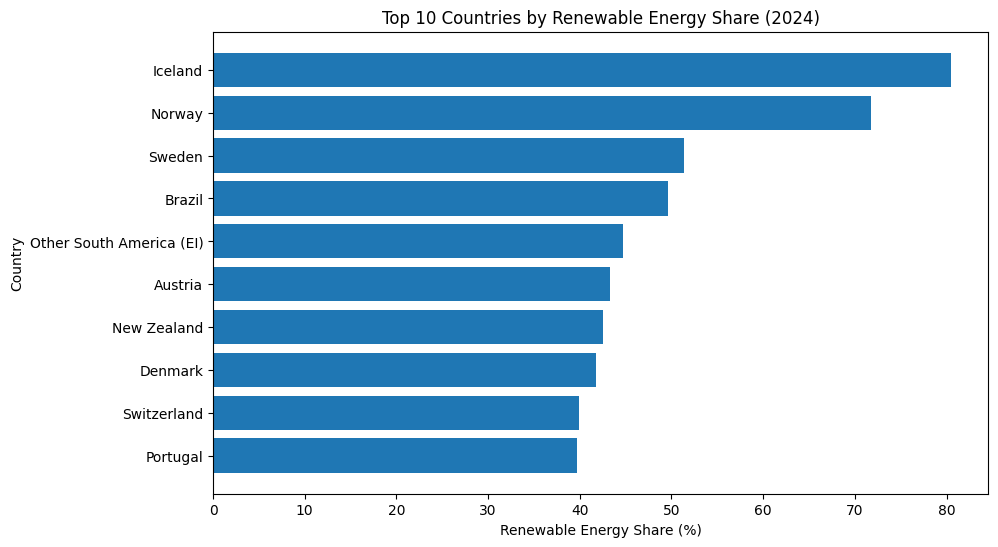

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_renewable["country"],
    top_renewable["renewables_share_energy"]
)

plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Country")
plt.title(
    f"Top 10 Countries by Renewable Energy Share ({latest_year})"
)

plt.gca().invert_yaxis()

plt.show()

In [ ]:
bottom_renewable = (
    latest[
        ["country", "renewables_share_energy"]
    ]
    .dropna()
    .sort_values(
        "renewables_share_energy"
    )
    .head(10)
)

print(bottom_renewable)

                          country  renewables_share_energy
21053                Turkmenistan                 0.006662
20762         Trinidad and Tobago                 0.010788
10878                      Kuwait                 0.075630
768                       Algeria                 0.241681
18762                   Singapore                 0.545238
16445  Other Northern Africa (EI)                 0.576997
10008                        Iraq                 0.584281
18520                Saudi Arabia                 0.728392
17803                       Qatar                 0.810713
2385                      Belarus                 0.968826



**2025 data**

In [ ]:
print(
    clean_df[
        clean_df["year"] == 2025
    ].isnull().sum()
)

country                         0
year                            0
iso_code                        2
population                      1
gdp                            37
                               ..
wind_share_elec                 0
wind_share_energy              37
renewable_share                37
renewable_electricity_share     0
energy_intensity               37
Length: 133, dtype: int64


In [ ]:
print(
    clean_df[
        clean_df["year"] == 2025
    ].shape
)

(37, 133)


**Renewable Energy vs. Carbon Intensity**

In [ ]:
analysis_df = latest[
    [
        "country",
        "renewables_share_energy",
        "carbon_intensity_elec"
    ]
].copy()

analysis_df = analysis_df.dropna()

print(analysis_df.shape)
print(analysis_df.head())

(71, 3)
         country  renewables_share_energy  carbon_intensity_elec
1150   Argentina                14.802979             344.829987
1717   Australia                14.733206             553.830017
1886     Austria                43.347355             103.209999
1927  Azerbaijan                 4.303142             632.760010
2221  Bangladesh                 1.095321             693.840027


In [ ]:
correlation = analysis_df[
    [
        "renewables_share_energy",
        "carbon_intensity_elec"
    ]
].corr()

print(correlation)

                         renewables_share_energy  carbon_intensity_elec
renewables_share_energy                 1.000000              -0.748452
carbon_intensity_elec                  -0.748452               1.000000


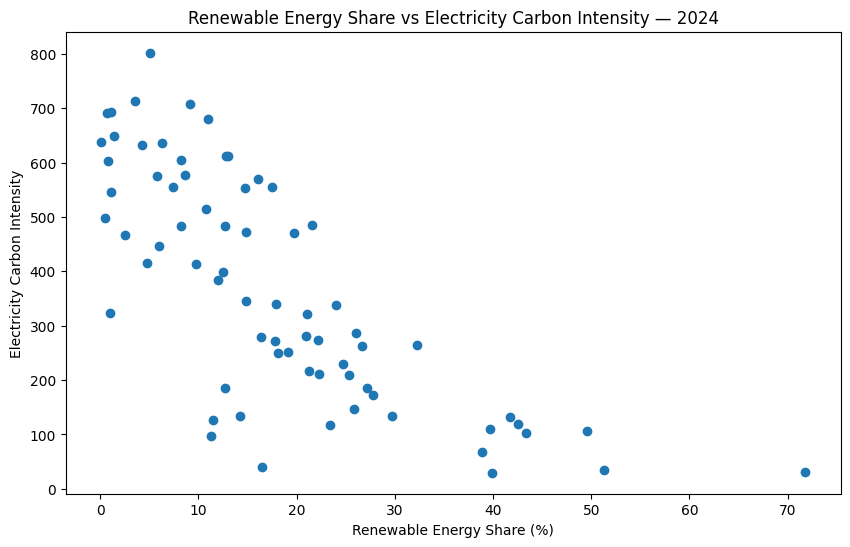

In [ ]:
from matplotlib.typing import ColorType
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    analysis_df["renewables_share_energy"],
    analysis_df["carbon_intensity_elec"],
)

plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Electricity Carbon Intensity")
plt.title(
    "Renewable Energy Share vs Electricity Carbon Intensity — 2024"
)

plt.show()

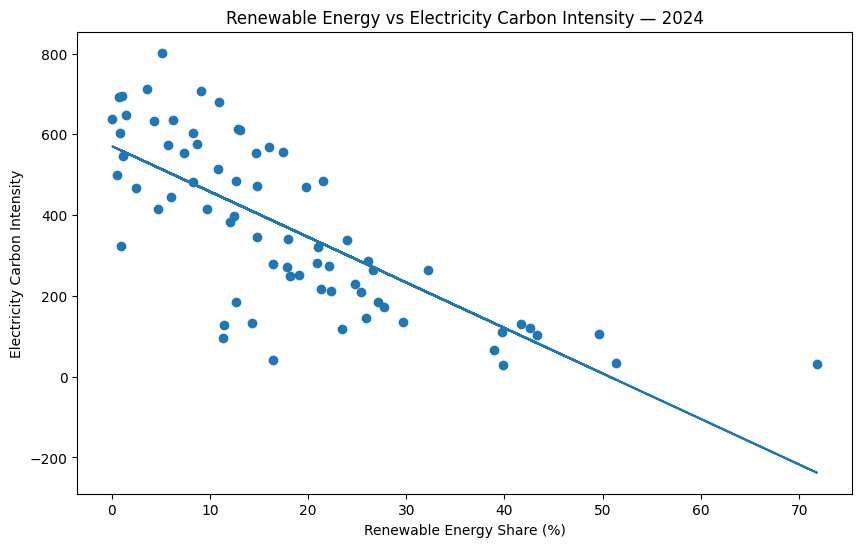

In [ ]:
import numpy as np

x = analysis_df["renewables_share_energy"]
y = analysis_df["carbon_intensity_elec"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y)

plt.plot(
    x,
    m * x + b
)

plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Electricity Carbon Intensity")
plt.title(
    "Renewable Energy vs Electricity Carbon Intensity — 2024"
)

plt.show()

In [ ]:
lowest_carbon = (
    analysis_df
    .sort_values("carbon_intensity_elec")
    .head(10)
)

print(lowest_carbon)

           country  renewables_share_energy  carbon_intensity_elec
20016  Switzerland                39.867901              29.570000
15066       Norway                71.811974              30.750000
19890       Sweden                51.317928              34.889999
7760        France                16.465389              40.830002
7634       Finland                38.894417              66.930000
18822     Slovakia                11.295315              96.550003
1886       Austria                43.347355             103.209999
3095        Brazil                49.615978             106.059998
17632     Portugal                39.740761             110.519997
11318    Lithuania                23.413942             117.809998


In [ ]:
highest_carbon = (
    analysis_df
    .sort_values(
        "carbon_intensity_elec",
        ascending=False
    )
    .head(10)
)

print(highest_carbon)

            country  renewables_share_energy  carbon_intensity_elec
10638    Kazakhstan                 5.119867             802.039978
19072  South Africa                 3.556729             713.169983
9633          India                 9.146443             707.450012
2221     Bangladesh                 1.095321             693.840027
18520  Saudi Arabia                 0.728392             691.950012
9758      Indonesia                10.954190             680.250000
9883           Iran                 1.432623             648.679993
10878        Kuwait                 0.075630             637.239990
20267        Taiwan                 6.268246             635.190002
1927     Azerbaijan                 4.303142             632.760010


**Analyze the energy transition over time**

In [ ]:
renewable_trend = (
    clean_df
    .groupby("year")["renewables_share_energy"]
    .mean()
    .reset_index()
)

renewable_trend = renewable_trend.dropna()

print(renewable_trend.tail())

     year  renewables_share_energy
120  2020                15.758705
121  2021                15.740277
122  2022                15.972893
123  2023                16.943299
124  2024                17.536184


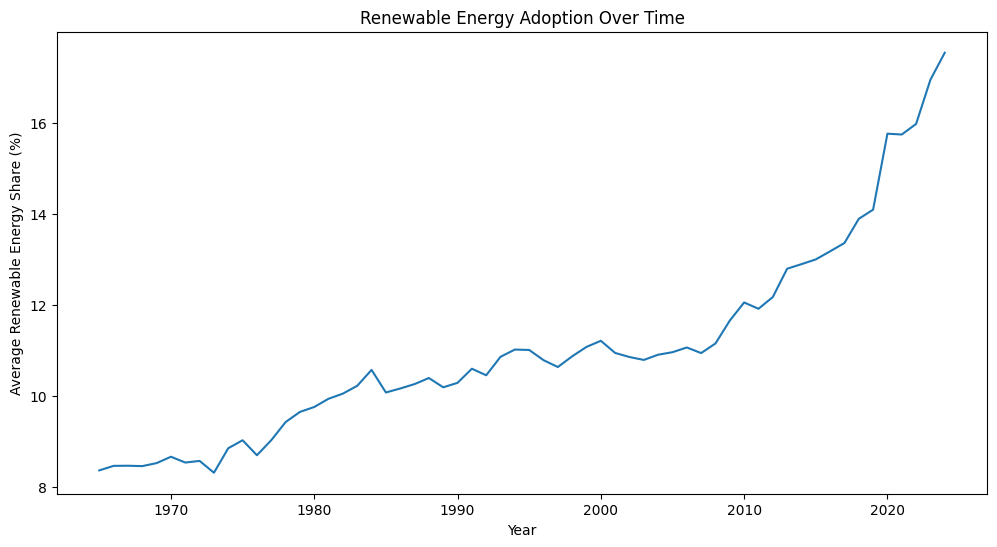

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    renewable_trend["year"],
    renewable_trend["renewables_share_energy"]
)

plt.xlabel("Year")
plt.ylabel("Average Renewable Energy Share (%)")
plt.title(
    "Renewable Energy Adoption Over Time"
)

plt.show()

**Finding the fastest-growing countries**

In [ ]:
country_growth = (
    clean_df[
        [
            "country",
            "year",
            "renewables_share_energy"
        ]
    ]
    .dropna()
    .sort_values(["country", "year"])
)

In [ ]:
growth = (
    country_growth
    .groupby("country")
    .agg(
        start_year=("year", "first"),
        start_renewable=("renewables_share_energy", "first"),
        end_year=("year", "last"),
        end_renewable=("renewables_share_energy", "last")
    )
    .reset_index()
)

In [ ]:
growth["renewable_share_change"] = (
    growth["end_renewable"]
    -
    growth["start_renewable"]
)

In [ ]:
top_growth = (
    growth
    .sort_values(
        "renewable_share_change",
        ascending=False
    )
    .head(10)
)

print(top_growth)

                            country  start_year  start_renewable  end_year  \
38                          Iceland        1965        23.830643      2024   
23                          Denmark        1965         0.041783      2024   
74         Other South America (EI)        1965         7.467041      2024   
89                    South America        1965        10.355970      2024   
91   South and Central America (EI)        1965         9.111880      2024   
108                       Venezuela        1965         1.988490      2024   
12                           Brazil        1965        26.318520      2024   
50                        Lithuania        1985         0.606795      2024   
33                          Germany        1965         1.518143      2024   
69                   Other CIS (EI)        1985        16.518509      2024   

     end_renewable  renewable_share_change  
38       80.498093               56.667450  
23       41.722164               41.680381  
74    

In [ ]:
print(correlation)

                         renewables_share_energy  carbon_intensity_elec
renewables_share_energy                 1.000000              -0.748452
carbon_intensity_elec                  -0.748452               1.000000


In [ ]:
print(lowest_carbon)

           country  renewables_share_energy  carbon_intensity_elec
20016  Switzerland                39.867901              29.570000
15066       Norway                71.811974              30.750000
19890       Sweden                51.317928              34.889999
7760        France                16.465389              40.830002
7634       Finland                38.894417              66.930000
18822     Slovakia                11.295315              96.550003
1886       Austria                43.347355             103.209999
3095        Brazil                49.615978             106.059998
17632     Portugal                39.740761             110.519997
11318    Lithuania                23.413942             117.809998


In [ ]:
print(highest_carbon)

            country  renewables_share_energy  carbon_intensity_elec
10638    Kazakhstan                 5.119867             802.039978
19072  South Africa                 3.556729             713.169983
9633          India                 9.146443             707.450012
2221     Bangladesh                 1.095321             693.840027
18520  Saudi Arabia                 0.728392             691.950012
9758      Indonesia                10.954190             680.250000
9883           Iran                 1.432623             648.679993
10878        Kuwait                 0.075630             637.239990
20267        Taiwan                 6.268246             635.190002
1927     Azerbaijan                 4.303142             632.760010


**Energy Efficiency Analysis**

In [ ]:
print(clean_df["energy_per_gdp"].describe())

count    7882.000000
mean        1.686106
std         1.637283
min         0.000000
25%         0.768618
50%         1.250316
75%         2.065455
max        25.252504
Name: energy_per_gdp, dtype: float64


In [ ]:
print(
    clean_df[
        ["country", "year", "gdp", "energy_per_gdp"]
    ].dropna().head(10)
)

         country  year           gdp  energy_per_gdp
105  Afghanistan  1980  1.532984e+10        0.413389
106  Afghanistan  1981  1.564534e+10        0.465925
107  Afghanistan  1982  1.598041e+10        0.493682
108  Afghanistan  1983  1.675533e+10        0.589792
109  Afghanistan  1984  1.707215e+10        0.581642
110  Afghanistan  1985  1.710848e+10        0.562865
111  Afghanistan  1986  1.764134e+10        0.566429
112  Afghanistan  1987  1.581082e+10        1.070794
113  Afghanistan  1988  1.449907e+10        2.144172
114  Afghanistan  1989  1.348950e+10        2.261656


In [ ]:
latest_efficiency_year = (
    clean_df.loc[
        clean_df["energy_per_gdp"].notna(),
        "year"
    ].max()
)

print("Latest efficiency year:", latest_efficiency_year)

Latest efficiency year: 2022


In [ ]:
efficiency_latest = clean_df[
    clean_df["year"] == latest_efficiency_year
].copy()

In [ ]:
efficiency_latest = efficiency_latest[
    efficiency_latest["energy_per_gdp"].notna()
]

In [ ]:
most_efficient = (
    efficiency_latest[
        ["country", "energy_per_gdp"]
    ]
    .sort_values("energy_per_gdp")
    .head(10)
)

print(most_efficient)

                            country  energy_per_gdp
18086                        Rwanda        0.238775
6784                       Ethiopia        0.298337
21360                        Uganda        0.307640
4323                           Chad        0.342866
4043       Central African Republic        0.374291
19579                     Sri Lanka        0.382365
20423                      Tanzania        0.387569
3557                        Burundi        0.396791
5641   Democratic Republic of Congo        0.407470
11842                        Malawi        0.416463


**Finding the least energy-efficient countries**

In [ ]:
least_efficient = (
    efficiency_latest[
        ["country", "energy_per_gdp"]
    ]
    .sort_values(
        "energy_per_gdp",
        ascending=False
    )
    .head(10)
)

print(least_efficient)

                   country  energy_per_gdp
21051         Turkmenistan        4.838528
20760  Trinidad and Tobago        4.613193
14860          North Korea        4.492852
22352            Venezuela        4.316129
2094               Bahrain        4.221349
9506               Iceland        3.977871
11276                Libya        2.398316
15807                 Oman        2.393848
18041               Russia        2.311911
23229             Zimbabwe        2.253915


**Does economic development relate to energy efficiency?**

In [ ]:
efficiency_analysis = efficiency_latest[
    [
        "country",
        "gdp",
        "energy_per_gdp"
    ]
].dropna()

In [ ]:
efficiency_correlation = efficiency_analysis[
    [
        "gdp",
        "energy_per_gdp"
    ]
].corr()

print(efficiency_correlation)

                     gdp  energy_per_gdp
gdp             1.000000        0.024041
energy_per_gdp  0.024041        1.000000


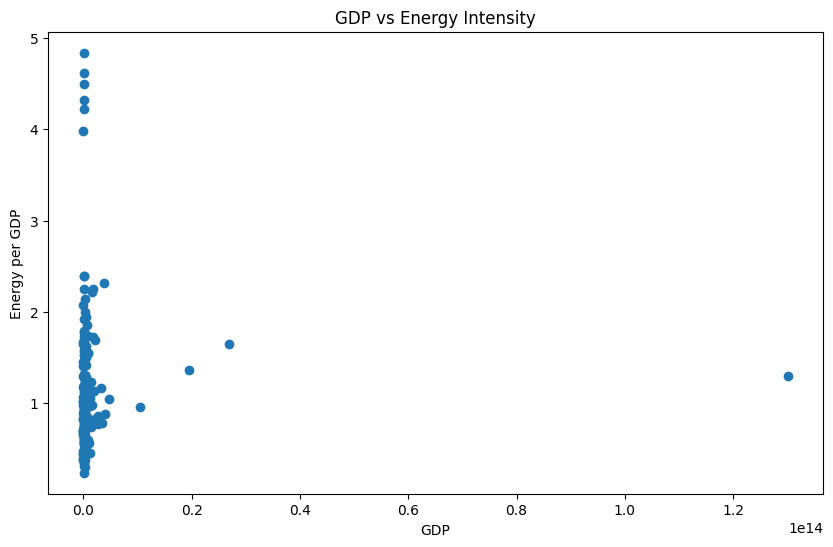

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    efficiency_analysis["gdp"],
    efficiency_analysis["energy_per_gdp"]
)

plt.xlabel("GDP")
plt.ylabel("Energy per GDP")
plt.title(
    "GDP vs Energy Intensity"
)

plt.show()

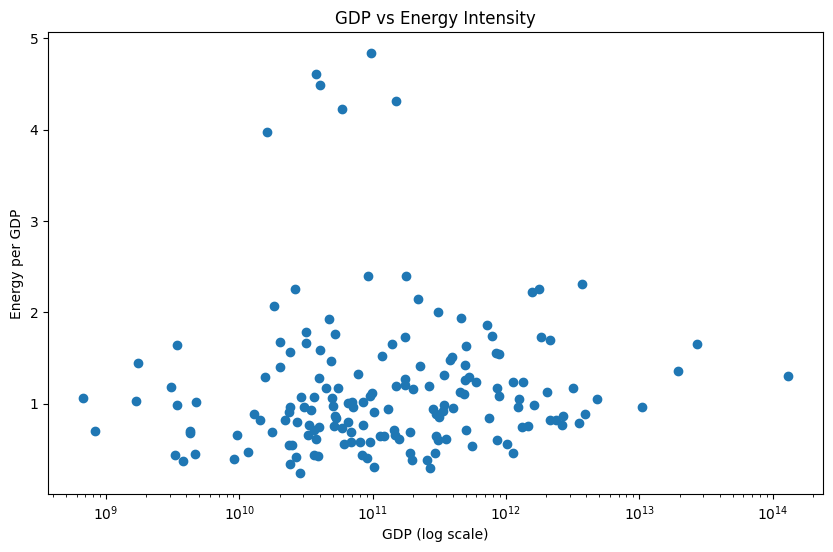

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    efficiency_analysis["gdp"],
    efficiency_analysis["energy_per_gdp"]
)

plt.xscale("log")

plt.xlabel("GDP (log scale)")
plt.ylabel("Energy per GDP")
plt.title(
    "GDP vs Energy Intensity"
)

plt.show()

**analyze improvement over time**

**Which countries improved their energy efficiency the most?**

In [ ]:
efficiency_history = clean_df[
    [
        "country",
        "year",
        "energy_per_gdp"
    ]
].dropna()

efficiency_history = efficiency_history.sort_values(
    ["country", "year"]
)

In [ ]:
efficiency_change = (
    efficiency_history
    .groupby("country")
    .agg(
        start_year=("year", "first"),
        start_intensity=("energy_per_gdp", "first"),
        end_year=("year", "last"),
        end_intensity=("energy_per_gdp", "last")
    )
    .reset_index()
)

In [ ]:
efficiency_change["efficiency_improvement_pct"] = (
    (
        efficiency_change["start_intensity"]
        -
        efficiency_change["end_intensity"]
    )
    /
    efficiency_change["start_intensity"]
) * 100

In [ ]:
top_efficiency_improvement = (
    efficiency_change
    .sort_values(
        "efficiency_improvement_pct",
        ascending=False
    )
    .head(10)
)

print(top_efficiency_improvement)

        country  start_year  start_intensity  end_year  end_intensity  \
89   Luxembourg        1965         7.005097      2022       1.074562   
42     Djibouti        1980         6.127152      2022       0.979731   
99     Mongolia        1980         6.940155      2022       1.169085   
1       Albania        1980         4.182372      2022       0.715069   
125     Romania        1965         3.851434      2022       0.713565   
88    Lithuania        1985         3.791224      2022       0.767156   
72      Ireland        1965         2.922223      2022       0.604595   
38      Czechia        1970         6.148674      2022       1.308400   
25   Cape Verde        1980         2.998393      2022       0.701825   
121      Poland        1965         4.112639      2022       0.964133   

     efficiency_improvement_pct  
89                    84.660283  
42                    84.010005  
99                    83.154772  
1                     82.902787  
125                   81.4

In [ ]:
print(most_efficient)

                            country  energy_per_gdp
18086                        Rwanda        0.238775
6784                       Ethiopia        0.298337
21360                        Uganda        0.307640
4323                           Chad        0.342866
4043       Central African Republic        0.374291
19579                     Sri Lanka        0.382365
20423                      Tanzania        0.387569
3557                        Burundi        0.396791
5641   Democratic Republic of Congo        0.407470
11842                        Malawi        0.416463


In [ ]:
print(least_efficient)

                   country  energy_per_gdp
21051         Turkmenistan        4.838528
20760  Trinidad and Tobago        4.613193
14860          North Korea        4.492852
22352            Venezuela        4.316129
2094               Bahrain        4.221349
9506               Iceland        3.977871
11276                Libya        2.398316
15807                 Oman        2.393848
18041               Russia        2.311911
23229             Zimbabwe        2.253915


In [ ]:
print(efficiency_correlation)

                     gdp  energy_per_gdp
gdp             1.000000        0.024041
energy_per_gdp  0.024041        1.000000


**Which countries have reduced their energy intensity the most over their available historical data?**

In [ ]:
efficiency_history = clean_df[
    [
        "country",
        "year",
        "energy_per_gdp"
    ]
].dropna()

efficiency_history = efficiency_history.sort_values(
    ["country", "year"]
)

print(efficiency_history.head())

         country  year  energy_per_gdp
105  Afghanistan  1980        0.413389
106  Afghanistan  1981        0.465925
107  Afghanistan  1982        0.493682
108  Afghanistan  1983        0.589792
109  Afghanistan  1984        0.581642


In [ ]:
efficiency_change = (
    efficiency_history
    .groupby("country")
    .agg(
        start_year=("year", "first"),
        start_intensity=("energy_per_gdp", "first"),
        end_year=("year", "last"),
        end_intensity=("energy_per_gdp", "last")
    )
    .reset_index()
)

In [ ]:
efficiency_change["efficiency_improvement_pct"] = (
    (
        efficiency_change["start_intensity"]
        - efficiency_change["end_intensity"]
    )
    / efficiency_change["start_intensity"]
) * 100

In [ ]:
top_efficiency_improvement = (
    efficiency_change
    .sort_values(
        "efficiency_improvement_pct",
        ascending=False
    )
    .head(10)
)

print(top_efficiency_improvement)

        country  start_year  start_intensity  end_year  end_intensity  \
89   Luxembourg        1965         7.005097      2022       1.074562   
42     Djibouti        1980         6.127152      2022       0.979731   
99     Mongolia        1980         6.940155      2022       1.169085   
1       Albania        1980         4.182372      2022       0.715069   
125     Romania        1965         3.851434      2022       0.713565   
88    Lithuania        1985         3.791224      2022       0.767156   
72      Ireland        1965         2.922223      2022       0.604595   
38      Czechia        1970         6.148674      2022       1.308400   
25   Cape Verde        1980         2.998393      2022       0.701825   
121      Poland        1965         4.112639      2022       0.964133   

     efficiency_improvement_pct  
89                    84.660283  
42                    84.010005  
99                    83.154772  
1                     82.902787  
125                   81.4

**Year-over-Year Renewable Growth**

In [ ]:
renewable_history = clean_df[
    [
        "country",
        "year",
        "renewables_share_energy"
    ]
].dropna()

renewable_history = renewable_history.sort_values(
    ["country", "year"]
)

In [ ]:
renewable_history["previous_year_share"] = (
    renewable_history
    .groupby("country")["renewables_share_energy"]
    .shift(1)
)

In [ ]:
renewable_history["yoy_change"] = (
    renewable_history["renewables_share_energy"]
    -
    renewable_history["previous_year_share"]
)

In [ ]:
print(renewable_history.head(20))

    country  year  renewables_share_energy  previous_year_share  yoy_change
214  Africa  1965                 5.419266                  NaN         NaN
215  Africa  1966                 5.772398             5.419266    0.353132
216  Africa  1967                 5.963763             5.772398    0.191365
217  Africa  1968                 6.605470             5.963763    0.641707
218  Africa  1969                 7.505726             6.605470    0.900256
219  Africa  1970                 8.649540             7.505726    1.143814
220  Africa  1971                 7.689221             8.649540   -0.960319
221  Africa  1972                 8.276323             7.689221    0.587102
222  Africa  1973                 8.068716             8.276323   -0.207607
223  Africa  1974                 8.736290             8.068716    0.667574
224  Africa  1975                 8.713099             8.736290   -0.023191
225  Africa  1976                 8.906370             8.713099    0.193272
226  Africa 

In [ ]:
biggest_yoy_increases = (
    renewable_history
    .dropna(subset=["yoy_change"])
    .sort_values(
        "yoy_change",
        ascending=False
    )
    .head(10)
)

print(biggest_yoy_increases)

                          country  year  renewables_share_energy  \
16579  Other Southern Africa (EI)  1978                40.165806   
16467    Other South America (EI)  1986                50.994331   
19570                   Sri Lanka  2013                23.640152   
9454                      Iceland  1970                40.211540   
17585                    Portugal  1977                24.302368   
16046              Other CIS (EI)  1993                37.532921   
16047              Other CIS (EI)  1994                47.090015   
5106                      Croatia  2013                25.559444   
11013                      Latvia  2017                29.606857   
22444                     Vietnam  1989                15.015821   

       previous_year_share  yoy_change  
16579             6.824865   33.340941  
16467            35.858402   15.135929  
19570            11.610240   12.029912  
9454             29.321117   10.890423  
17585            13.495464   10.806904  
16046

In [ ]:
biggest_yoy_decreases = (
    renewable_history
    .dropna(subset=["yoy_change"])
    .sort_values(
        "yoy_change"
    )
    .head(10)
)

print(biggest_yoy_decreases)

                          country  year  renewables_share_energy  \
16591  Other Southern Africa (EI)  1990                14.928985   
17597                    Portugal  1989                 9.380951   
19553                   Sri Lanka  1996                21.368847   
19571                   Sri Lanka  2014                14.695231   
5104                      Croatia  2011                14.713418   
14883             North Macedonia  2011                11.084478   
17625                    Portugal  2017                20.605705   
11014                      Latvia  2018                22.386730   
9705                    Indonesia  1971                 3.767792   
17578                    Portugal  1970                22.027586   

       previous_year_share  yoy_change  
16591            28.287062  -13.358077  
17597            20.145460  -10.764509  
19553            31.403461  -10.034615  
19571            23.640152   -8.944921  
5104             22.715929   -8.002511  
14883

**Remove regional/aggregate records**

In [ ]:
print(clean_df[["country", "iso_code"]].head(20))

          country iso_code
0   ASEAN (Ember)      NaN
1   ASEAN (Ember)      NaN
2   ASEAN (Ember)      NaN
3   ASEAN (Ember)      NaN
4   ASEAN (Ember)      NaN
5   ASEAN (Ember)      NaN
6   ASEAN (Ember)      NaN
7   ASEAN (Ember)      NaN
8   ASEAN (Ember)      NaN
9   ASEAN (Ember)      NaN
10  ASEAN (Ember)      NaN
11  ASEAN (Ember)      NaN
12  ASEAN (Ember)      NaN
13  ASEAN (Ember)      NaN
14  ASEAN (Ember)      NaN
15  ASEAN (Ember)      NaN
16  ASEAN (Ember)      NaN
17  ASEAN (Ember)      NaN
18  ASEAN (Ember)      NaN
19  ASEAN (Ember)      NaN


In [ ]:
print(
    clean_df[clean_df["iso_code"].isna()]["country"].unique()[:50]
)

['ASEAN (Ember)' 'Africa' 'Africa (EI)' 'Africa (EIA)' 'Africa (Ember)'
 'Africa (Shift)' 'Asia' 'Asia (Ember)' 'Asia Pacific (EI)'
 'Asia and Oceania (EIA)' 'Asia and Oceania (Shift)'
 'Australia and New Zealand (EIA)' 'CIS (EI)' 'Central America (EI)'
 'Central and South America (EIA)' 'Central and South America (Shift)'
 'Czechoslovakia' 'EU (Ember)' 'EU28 (Shift)' 'East Germany'
 'Eastern Africa (EI)' 'Eastern Europe and Eurasia (EIA)' 'Eurasia (EIA)'
 'Eurasia (Shift)' 'Europe' 'Europe (EI)' 'Europe (EIA)' 'Europe (Ember)'
 'Europe (Shift)' 'European Union (27)' 'G20 (Ember)' 'G7 (Ember)'
 'High-income countries' 'Kosovo' 'Latin America and Caribbean (Ember)'
 'Low-income countries' 'Lower-middle-income countries'
 'Middle Africa (EI)' 'Middle East (EI)' 'Middle East (EIA)'
 'Middle East (Ember)' 'Middle East (Shift)' 'Non-OECD (EI)'
 'Non-OECD (EIA)' 'Non-OPEC (EI)' 'Non-OPEC (EIA)' 'North America'
 'North America (EI)' 'North America (Ember)' 'North America (Shift)']


In [ ]:
country_df = clean_df[
    clean_df["iso_code"].notna()
].copy()

In [ ]:
print("Original rows:", len(clean_df))
print("Country rows:", len(country_df))
print("Countries:", country_df["country"].nunique())

Original rows: 23232
Country rows: 17134
Countries: 220


In [ ]:
renewable_history = country_df[
    [
        "country",
        "year",
        "renewables_share_energy"
    ]
].dropna()

renewable_history = renewable_history.sort_values(
    ["country", "year"]
)

In [ ]:
renewable_history["previous_year_share"] = (
    renewable_history
    .groupby("country")["renewables_share_energy"]
    .shift(1)
)

In [ ]:
renewable_history["yoy_change"] = (
    renewable_history["renewables_share_energy"]
    -
    renewable_history["previous_year_share"]
)

**Finding the biggest annual renewable increases**

In [ ]:
biggest_yoy_increases = (
    renewable_history
    .dropna(subset=["yoy_change"])
    .sort_values(
        "yoy_change",
        ascending=False
    )
    .head(10)
)

print(
    biggest_yoy_increases[
        [
            "country",
            "year",
            "previous_year_share",
            "renewables_share_energy",
            "yoy_change"
        ]
    ]
)

               country  year  previous_year_share  renewables_share_energy  \
19570        Sri Lanka  2013            11.610240                23.640152   
9454           Iceland  1970            29.321117                40.211540   
17585         Portugal  1977            13.495464                24.302368   
5106           Croatia  2013            16.074078                25.559444   
11013           Latvia  2017            21.134270                29.606857   
22444          Vietnam  1989             6.642619                15.015821   
19541        Sri Lanka  1984            13.282707                21.652941   
17618         Portugal  2010            18.133030                26.401539   
14882  North Macedonia  2010            10.849470                18.923309   
22350        Venezuela  2020            24.050093                32.081184   

       yoy_change  
19570   12.029912  
9454    10.890423  
17585   10.806904  
5106     9.485367  
11013    8.472588  
22444    8.373202  
1

In [ ]:
renewable_history["yoy_change_pp"] = (
    renewable_history["renewables_share_energy"]
    -
    renewable_history["previous_year_share"]
)

In [ ]:
renewable_history["yoy_growth_pct"] = (
    (
        renewable_history["renewables_share_energy"]
        -
        renewable_history["previous_year_share"]
    )
    /
    renewable_history["previous_year_share"]
) * 100

**renewable-transition metric**

In [ ]:
renewable_change = (
    renewable_history
    .groupby("country")
    .agg(
        start_year=("year", "first"),
        start_share=("renewables_share_energy", "first"),
        end_year=("year", "last"),
        end_share=("renewables_share_energy", "last")
    )
    .reset_index()
)

In [ ]:
renewable_change["renewable_improvement_pp"] = (
    renewable_change["end_share"]
    -
    renewable_change["start_share"]
)

In [ ]:
top_transition_countries = (
    renewable_change
    .sort_values(
        "renewable_improvement_pp",
        ascending=False
    )
    .head(10)
)

print(top_transition_countries)

           country  start_year  start_share  end_year  end_share  \
27         Iceland        1965    23.830643      2024  80.498093   
17         Denmark        1965     0.041783      2024  41.722164   
77       Venezuela        1965     1.988490      2024  25.840307   
8           Brazil        1965    26.318520      2024  49.615978   
39       Lithuania        1985     0.606795      2024  23.413942   
23         Germany        1965     1.518143      2024  23.968008   
38          Latvia        1985     7.823849      2024  29.669052   
74  United Kingdom        1965     0.553517      2024  21.292688   
3          Austria        1965    23.939529      2024  43.347355   
78         Vietnam        1965     3.213048      2024  21.534109   

    renewable_improvement_pp  
27                 56.667450  
17                 41.680381  
77                 23.851817  
8                  23.297459  
39                 22.807147  
23                 22.449865  
38                 21.845203  
74 

**Climate Transition Score**

In [ ]:
print("Renewable:",
      country_df[
          country_df["year"] == 2024
      ]["renewables_share_energy"].notna().sum())

print("Carbon:",
      country_df[
          country_df["year"] == 2024
      ]["carbon_intensity_elec"].notna().sum())

print("Energy efficiency:",
      country_df[
          country_df["year"] == 2024
      ]["energy_per_gdp"].notna().sum())

Renewable: 79
Carbon: 89
Energy efficiency: 0


In [ ]:
print(
    country_df.groupby("year")[
        [
            "renewables_share_energy",
            "carbon_intensity_elec",
            "energy_per_gdp"
        ]
    ].count().tail(15)
)

      renewables_share_energy  carbon_intensity_elec  energy_per_gdp
year                                                                
2011                       79                    211             165
2012                       79                    212             165
2013                       79                    212             165
2014                       79                    212             165
2015                       79                    212             165
2016                       79                    212             165
2017                       79                    212             165
2018                       79                    212             165
2019                       79                    212             165
2020                       79                    212             165
2021                       79                    212             165
2022                       79                    212             165
2023                       79     

In [ ]:
year_availability = (
    country_df
    .groupby("year")[
        [
            "renewables_share_energy",
            "carbon_intensity_elec",
            "energy_per_gdp"
        ]
    ]
    .count()
)

year_availability["complete_metrics"] = (
    (year_availability["renewables_share_energy"] > 0)
    &
    (year_availability["carbon_intensity_elec"] > 0)
    &
    (year_availability["energy_per_gdp"] > 0)
)

print(
    year_availability[
        year_availability["complete_metrics"]
    ].tail(10)
)

      renewables_share_energy  carbon_intensity_elec  energy_per_gdp  \
year                                                                   
2013                       79                    212             165   
2014                       79                    212             165   
2015                       79                    212             165   
2016                       79                    212             165   
2017                       79                    212             165   
2018                       79                    212             165   
2019                       79                    212             165   
2020                       79                    212             165   
2021                       79                    212             165   
2022                       79                    212             165   

      complete_metrics  
year                    
2013              True  
2014              True  
2015              True  
2016      

In [ ]:
common_years = year_availability[
    year_availability["complete_metrics"]
].index

latest_common_year = common_years.max()

print("Latest common year:", latest_common_year)

Latest common year: 2022


In [ ]:
score_df = country_df[
    country_df["year"] == latest_common_year
][
    [
        "country",
        "renewables_share_energy",
        "carbon_intensity_elec",
        "energy_per_gdp"
    ]
].dropna()

print(score_df.shape)
print(score_df.head())

(79, 4)
         country  renewables_share_energy  carbon_intensity_elec  \
766      Algeria                 0.227914             633.650024   
1148   Argentina                12.009511             392.690002   
1715   Australia                13.247022             577.859985   
1884     Austria                35.134083             140.949997   
1925  Azerbaijan                 2.188249             671.390015   

      energy_per_gdp  
766         1.232331  
1148        1.171160  
1715        1.235476  
1884        0.957394  
1925        1.199097  


**Build the score using 2022**

In [ ]:
score_df = country_df[
    country_df["year"] == latest_common_year
][
    [
        "country",
        "renewables_share_energy",
        "carbon_intensity_elec",
        "energy_per_gdp"
    ]
].dropna()

print(score_df.shape)
print(score_df.head())

(79, 4)
         country  renewables_share_energy  carbon_intensity_elec  \
766      Algeria                 0.227914             633.650024   
1148   Argentina                12.009511             392.690002   
1715   Australia                13.247022             577.859985   
1884     Austria                35.134083             140.949997   
1925  Azerbaijan                 2.188249             671.390015   

      energy_per_gdp  
766         1.232331  
1148        1.171160  
1715        1.235476  
1884        0.957394  
1925        1.199097  


**Normalize the three metrics**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

score_df[
    [
        "renewable_normalized",
        "carbon_normalized",
        "efficiency_normalized"
    ]
] = scaler.fit_transform(
    score_df[
        [
            "renewables_share_energy",
            "carbon_intensity_elec",
            "energy_per_gdp"
        ]
    ]
)

In [ ]:
score_df["renewable_score"] = (
    score_df["renewable_normalized"]
)

score_df["carbon_score"] = (
    1 - score_df["carbon_normalized"]
)

score_df["efficiency_score"] = (
    1 - score_df["efficiency_normalized"]
)

**Climate Transition Score**

In [ ]:
score_df["transition_score"] = (
    score_df["renewable_score"] * 0.40
    +
    score_df["carbon_score"] * 0.40
    +
    score_df["efficiency_score"] * 0.20
)

score_df["transition_score_100"] = (
    score_df["transition_score"] * 100
)

In [ ]:
score_df = score_df.sort_values(
    "transition_score_100",
    ascending=False
)

In [ ]:
top_leaders = score_df.head(10)

print(
    top_leaders[
        [
            "country",
            "renewables_share_energy",
            "carbon_intensity_elec",
            "energy_per_gdp",
            "transition_score_100"
        ]
    ]
)

           country  renewables_share_energy  carbon_intensity_elec  \
15064       Norway                69.648407              29.639999   
9506       Iceland                82.075333              27.680000   
19888       Sweden                52.433502              41.029999   
3093        Brazil                47.659924             103.389999   
13863  New Zealand                43.294933             112.379997   
20014  Switzerland                31.095837              37.259998   
5766       Denmark                40.791603             203.580002   
1884       Austria                35.134083             140.949997   
7632       Finland                34.896740             129.970001   
11018       Latvia                26.645931             135.190002   

       energy_per_gdp  transition_score_100  
15064        1.106233             90.633100  
9506         3.977871             83.862771  
19888        1.257917             81.205603  
3093         1.170767             77.319063  

In [ ]:
def classify_transition(score):
    if score >= 70:
        return "Transition Leader"
    elif score >= 40:
        return "Transitioning"
    else:
        return "High Priority"

In [ ]:
score_df["transition_category"] = (
    score_df["transition_score_100"]
    .apply(classify_transition)
)

In [ ]:
print(
    score_df[
        [
            "country",
            "transition_score_100",
            "transition_category"
        ]
    ].head(20)
)

              country  transition_score_100 transition_category
15064          Norway             90.633100   Transition Leader
9506          Iceland             83.862771   Transition Leader
19888          Sweden             81.205603   Transition Leader
3093           Brazil             77.319063   Transition Leader
13863     New Zealand             74.958432   Transition Leader
20014     Switzerland             74.182726   Transition Leader
5766          Denmark             73.180102   Transition Leader
1884          Austria             70.996605   Transition Leader
7632          Finland             69.166237       Transitioning
11018          Latvia             67.963872       Transitioning
4698         Colombia             66.298513       Transitioning
17630        Portugal             65.557928       Transitioning
6314          Ecuador             65.054257       Transitioning
5115          Croatia             63.046482       Transitioning
7758           France             62.936

In [ ]:
print(
    score_df["transition_category"].value_counts()
)

transition_category
Transitioning        52
High Priority        19
Transition Leader     8
Name: count, dtype: int64


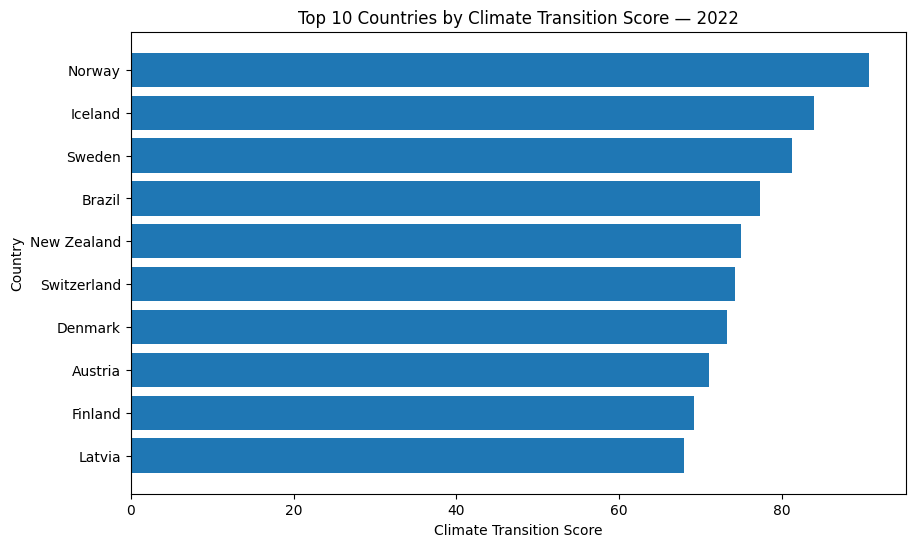

In [ ]:
top10 = score_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["country"],
    top10["transition_score_100"]
)

plt.xlabel("Climate Transition Score")
plt.ylabel("Country")
plt.title(
    "Top 10 Countries by Climate Transition Score — 2022"
)

plt.gca().invert_yaxis()

plt.show()

**cleaned  data**

In [ ]:
country_df.to_csv(
    "climate_energy_cleaned.csv",
    index=False
)

In [ ]:
score_df.to_csv(
    "climate_transition_score.csv",
    index=False
)

****

**sql ingestion**

In [ ]:
columns_to_check = [
    "renewables_share_energy",
    "renewables_share_elec",
    "renewable_share",
    "renewable_electricity_share",
    "energy_per_gdp",
    "energy_intensity"
]

print(clean_df[columns_to_check].describe().T)

                              count       mean        std  min       25%  \
renewables_share_energy      6379.0  11.118055  13.269040  0.0  2.126912   
renewables_share_elec        7646.0  29.786536  30.545185  0.0  3.513810   
renewable_share              6379.0  11.118055  13.269040  0.0  2.126912   
renewable_electricity_share  7646.0  29.786536  30.545185  0.0  3.513810   
energy_per_gdp               7882.0   1.686106   1.637283  0.0  0.768618   
energy_intensity             7882.0   1.686106   1.637283  0.0  0.768618   

                                   50%        75%         max  
renewables_share_energy       6.550673  15.007385   86.126358  
renewables_share_elec        18.499984  50.000000  100.000000  
renewable_share               6.550673  15.007385   86.126358  
renewable_electricity_share  18.499984  50.000000  100.000000  
energy_per_gdp                1.250316   2.065455   25.252504  
energy_intensity              1.250316   2.065455   25.252504  


In [ ]:
print(
    clean_df[
        columns_to_check
    ].corr()
)

                             renewables_share_energy  renewables_share_elec  \
renewables_share_energy                     1.000000               0.921689   
renewables_share_elec                       0.921689               1.000000   
renewable_share                             1.000000               0.921689   
renewable_electricity_share                 0.921689               1.000000   
energy_per_gdp                             -0.106511              -0.284318   
energy_intensity                           -0.106511              -0.284318   

                             renewable_share  renewable_electricity_share  \
renewables_share_energy             1.000000                     0.921689   
renewables_share_elec               0.921689                     1.000000   
renewable_share                     1.000000                     0.921689   
renewable_electricity_share         0.921689                     1.000000   
energy_per_gdp                     -0.106511                 

In [ ]:
print(
    clean_df[
        ["energy_per_gdp", "energy_intensity"]
    ].describe()
)

       energy_per_gdp  energy_intensity
count     7882.000000       7882.000000
mean         1.686106          1.686106
std          1.637283          1.637283
min          0.000000          0.000000
25%          0.768618          0.768618
50%          1.250316          1.250316
75%          2.065455          2.065455
max         25.252504         25.252504


In [ ]:
print(
    clean_df[
        ["energy_per_gdp", "energy_intensity"]
    ].corr()
)

                  energy_per_gdp  energy_intensity
energy_per_gdp               1.0               1.0
energy_intensity             1.0               1.0


In [ ]:
sql_df = country_df[
    [
        "country",
        "year",
        "iso_code",
        "population",
        "gdp",

        "renewables_share_energy",
        "renewables_share_elec",

        "carbon_intensity_elec",

        "energy_per_gdp",
        "energy_per_capita",

        "electricity_generation",
        "electricity_demand",

        "fossil_share_energy",
        "fossil_share_elec",

        "low_carbon_share_energy",
        "low_carbon_share_elec",

        "solar_share_energy",
        "solar_share_elec",

        "wind_share_energy",
        "wind_share_elec",

        "hydro_share_energy",
        "hydro_share_elec",

        "nuclear_share_energy",
        "nuclear_share_elec",

        "greenhouse_gas_emissions"
    ]
].copy()

In [ ]:
print(sql_df.shape)
print(sql_df.head())

(17134, 25)
        country  year iso_code  population  gdp  renewables_share_energy  \
25  Afghanistan  1900      AFG   4707744.0  NaN                      NaN   
26  Afghanistan  1901      AFG   4751177.0  NaN                      NaN   
27  Afghanistan  1902      AFG   4802500.0  NaN                      NaN   
28  Afghanistan  1903      AFG   4861833.0  NaN                      NaN   
29  Afghanistan  1904      AFG   4921891.0  NaN                      NaN   

    renewables_share_elec  carbon_intensity_elec  energy_per_gdp  \
25                    NaN                    NaN             NaN   
26                    NaN                    NaN             NaN   
27                    NaN                    NaN             NaN   
28                    NaN                    NaN             NaN   
29                    NaN                    NaN             NaN   

    energy_per_capita  ...  low_carbon_share_elec  solar_share_energy  \
25                NaN  ...                    NaN

In [ ]:
print(clean_df[columns_to_check].describe().T)

                              count       mean        std  min       25%  \
renewables_share_energy      6379.0  11.118055  13.269040  0.0  2.126912   
renewables_share_elec        7646.0  29.786536  30.545185  0.0  3.513810   
renewable_share              6379.0  11.118055  13.269040  0.0  2.126912   
renewable_electricity_share  7646.0  29.786536  30.545185  0.0  3.513810   
energy_per_gdp               7882.0   1.686106   1.637283  0.0  0.768618   
energy_intensity             7882.0   1.686106   1.637283  0.0  0.768618   

                                   50%        75%         max  
renewables_share_energy       6.550673  15.007385   86.126358  
renewables_share_elec        18.499984  50.000000  100.000000  
renewable_share               6.550673  15.007385   86.126358  
renewable_electricity_share  18.499984  50.000000  100.000000  
energy_per_gdp                1.250316   2.065455   25.252504  
energy_intensity              1.250316   2.065455   25.252504  


In [ ]:
print(clean_df[columns_to_check].corr())

                             renewables_share_energy  renewables_share_elec  \
renewables_share_energy                     1.000000               0.921689   
renewables_share_elec                       0.921689               1.000000   
renewable_share                             1.000000               0.921689   
renewable_electricity_share                 0.921689               1.000000   
energy_per_gdp                             -0.106511              -0.284318   
energy_intensity                           -0.106511              -0.284318   

                             renewable_share  renewable_electricity_share  \
renewables_share_energy             1.000000                     0.921689   
renewables_share_elec               0.921689                     1.000000   
renewable_share                     1.000000                     0.921689   
renewable_electricity_share         0.921689                     1.000000   
energy_per_gdp                     -0.106511                 

In [ ]:
sql_df["population"] = (
    sql_df["population"]
    .round()
    .astype("Int64")
)

In [ ]:
sql_df = country_df[
    [
        "country",
        "year",
        "iso_code",
        "population",
        "gdp",

        "renewables_share_energy",
        "renewables_share_elec",

        "carbon_intensity_elec",

        "energy_per_gdp",
        "energy_per_capita",

        "electricity_generation",
        "electricity_demand",

        "fossil_share_energy",
        "fossil_share_elec",

        "low_carbon_share_energy",
        "low_carbon_share_elec",

        "solar_share_energy",
        "solar_share_elec",

        "wind_share_energy",
        "wind_share_elec",

        "hydro_share_energy",
        "hydro_share_elec",

        "nuclear_share_energy",
        "nuclear_share_elec",

        "greenhouse_gas_emissions"
    ]
].copy()

In [ ]:
print(sql_df.shape)
print(sql_df.columns.tolist())

(17134, 25)
['country', 'year', 'iso_code', 'population', 'gdp', 'renewables_share_energy', 'renewables_share_elec', 'carbon_intensity_elec', 'energy_per_gdp', 'energy_per_capita', 'electricity_generation', 'electricity_demand', 'fossil_share_energy', 'fossil_share_elec', 'low_carbon_share_energy', 'low_carbon_share_elec', 'solar_share_energy', 'solar_share_elec', 'wind_share_energy', 'wind_share_elec', 'hydro_share_energy', 'hydro_share_elec', 'nuclear_share_energy', 'nuclear_share_elec', 'greenhouse_gas_emissions']


In [ ]:
sql_df.to_csv(
    "climate_energy_sql.csv",
    index=False,
    na_rep=""
)